# Combined genetic-driver + Zebra classifiers

AUC is calculated from constructed ROC curves. All threshold-dependent validation metrics use the right-most ROC operating point with FPR <= 0.05.

In [1]:
import matplotlib.pyplot as plt


In [2]:
import os
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from lightgbm import LGBMClassifier, early_stopping
from sklearn.model_selection import train_test_split, ParameterSampler
from sklearn.metrics import (
    roc_curve,
    auc,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
from scipy.stats import randint, uniform, loguniform
from tqdm.auto import tqdm

%matplotlib inline


FPR_TARGET = 0.05

In [3]:
def roc_performance(
    target_name,
    model_name,
    y_true,
    prediction,
    fpr_target=FPR_TARGET,
):
    y_true = np.asarray(y_true).astype(int)
    prediction = np.asarray(prediction, dtype=float)

    roc_fpr, roc_tpr, thresholds = roc_curve(y_true, prediction)
    roc_auc = auc(roc_fpr, roc_tpr)

    # Right-most ROC point that does not exceed the requested FPR.
    i = np.where(roc_fpr <= fpr_target)[0][-1]
    threshold = thresholds[i]

    pred_binary = (prediction >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        pred_binary,
        labels=[0, 1],
    ).ravel()

    achieved_fpr = fp / (fp + tn) if (fp + tn) else np.nan
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    ppv = tp / (tp + fp) if (tp + fp) else np.nan
    npv = tn / (tn + fn) if (tn + fn) else np.nan

    perf = {
        "model": model_name,
        "target_name": target_name,
        "n_pos": int((y_true == 1).sum()),
        "n_neg": int((y_true == 0).sum()),
        "auc": roc_auc,
        "fpr_target": fpr_target,
        "threshold": threshold,
        "fpr": achieved_fpr,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "ppv": ppv,
        "npv": npv,
        "accuracy": accuracy_score(y_true, pred_binary),
        "f1": f1_score(y_true, pred_binary, zero_division=0),
        "LR+": sensitivity / achieved_fpr
        if pd.notna(achieved_fpr) and achieved_fpr > 0
        else np.inf,
        "LR-": (1 - sensitivity) / specificity
        if pd.notna(specificity) and specificity > 0
        else np.inf,
    }

    roc_df = pd.DataFrame({
        "fpr": roc_fpr,
        "tpr": roc_tpr,
        "threshold": thresholds,
    })

    return perf, roc_df

In [4]:
BASE_DATA = pd.read_csv("ILD_TOP_DRIVERS_DATA.csv").drop(
    columns=["target"], errors="ignore"
)

NEW_TARGETS = (
    pd.read_csv("REPHENOTYPES FOR IC.csv")
    .replace({"N": 0, "Y": 1, "y": 1, "n": 0, "na": np.nan})
    .rename(columns={"arb_person_id": "patient_id"})
)

PREDS = pd.read_parquet("PREDICTIONS_104W_PRED_WINDOW.parquet")

TARGET_NAMES = [c for c in NEW_TARGETS.columns if c != "patient_id"]

os.makedirs("./RESULTS/COMBINED", exist_ok=True)

print("Targets:")
for TARGET_NAME in TARGET_NAMES:
    print(" -", TARGET_NAME)


Targets:
 - FILD or FILA ADJUDICATED
 - NONFIBROTIC ILD ADJUDICATED
 - NON FIBROTIC ILA ADJUDICATED



FILD or FILA ADJUDICATED


FILD or FILA ADJUDICATED: random search:   0%|          | 0/50 [00:00<?, ?it/s]

/home/ishanu/.local/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/ishanu/.local/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/ishanu/.local/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/ishanu/.local/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, ev

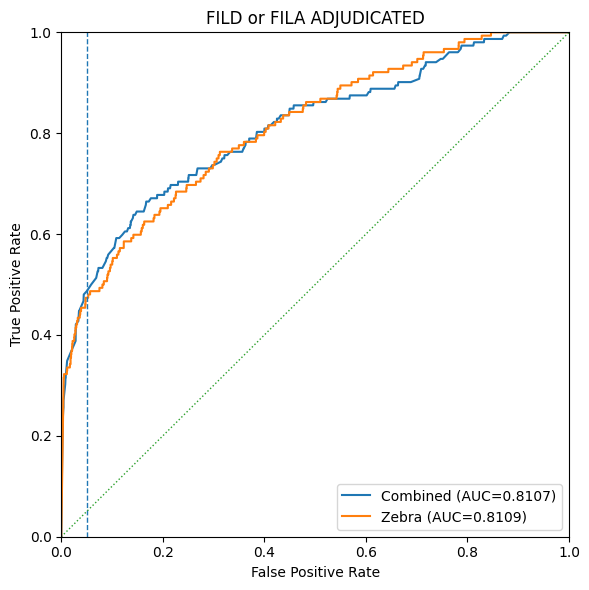

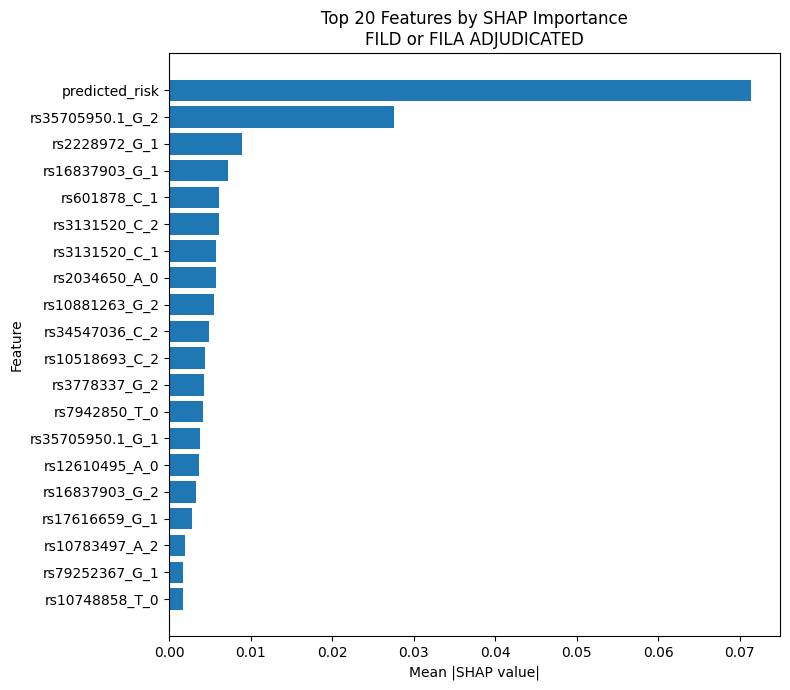

Validation: 7,695 (152 positive) | Combined AUC: 0.8107 | Zebra AUC: 0.8109

NONFIBROTIC ILD ADJUDICATED


NONFIBROTIC ILD ADJUDICATED: random search:   0%|          | 0/50 [00:00<?, ?it/s]

/home/ishanu/.local/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/ishanu/.local/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/ishanu/.local/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/ishanu/.local/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, ev

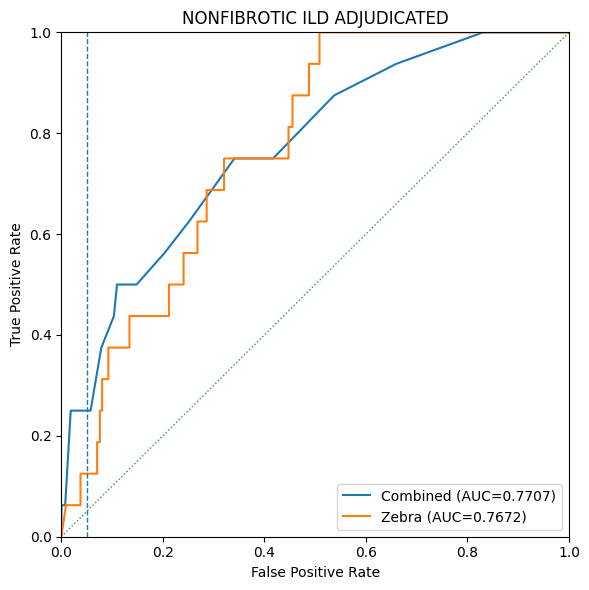

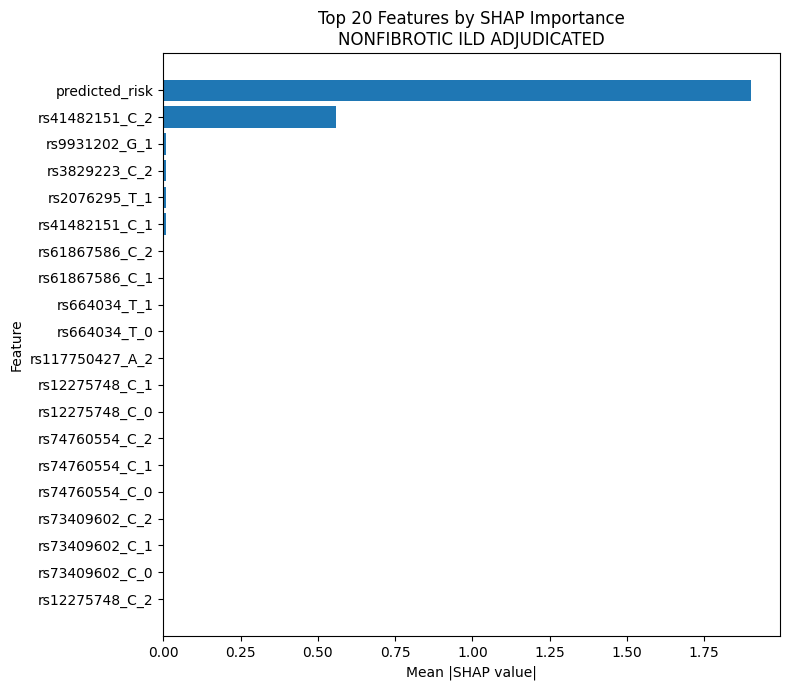

Validation: 7,695 (16 positive) | Combined AUC: 0.7707 | Zebra AUC: 0.7672

NON FIBROTIC ILA ADJUDICATED


NON FIBROTIC ILA ADJUDICATED: random search:   0%|          | 0/50 [00:00<?, ?it/s]

/home/ishanu/.local/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/ishanu/.local/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/ishanu/.local/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/ishanu/.local/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, ev

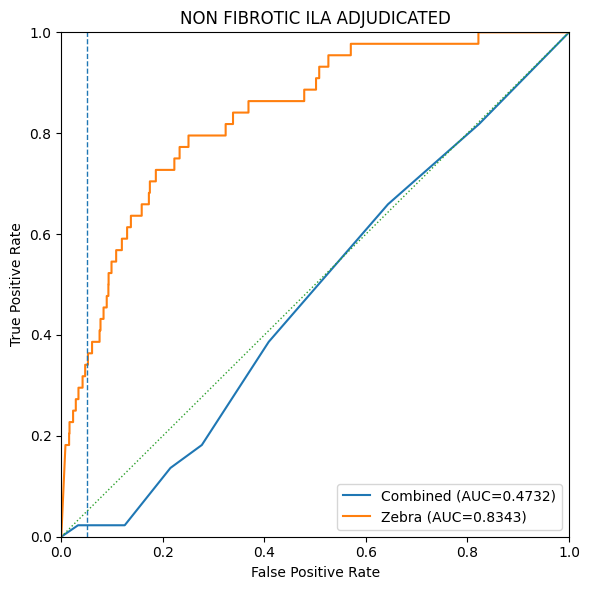

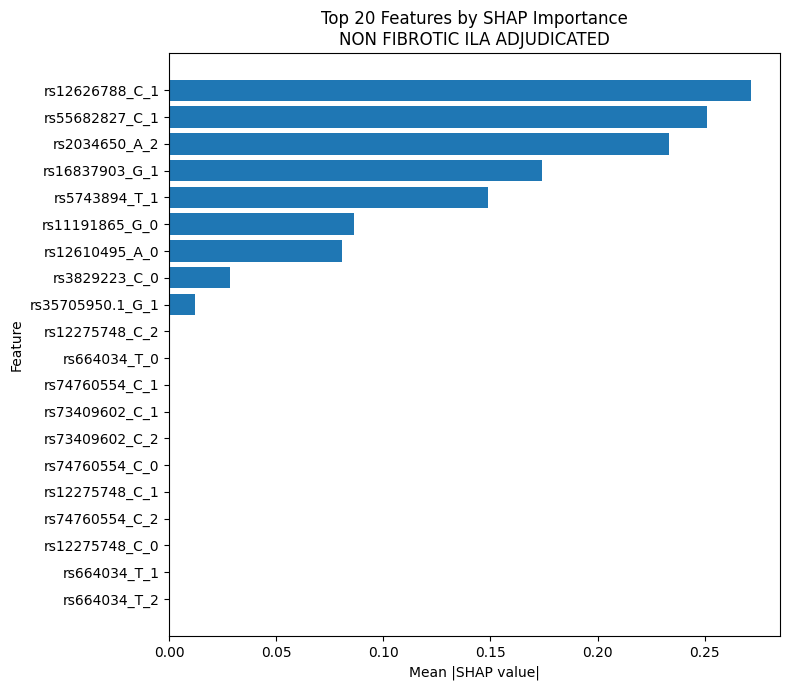

Validation: 7,695 (44 positive) | Combined AUC: 0.4732 | Zebra AUC: 0.8343


In [14]:
RUN_PERFORMANCE = []

for TARGET_NAME in TARGET_NAMES:

    print(f"\n{'=' * 100}")
    print(TARGET_NAME)
    print(f"{'=' * 100}")

    TARGET_DIR = f"./RESULTS/COMBINED/{TARGET_NAME}"
    os.makedirs(TARGET_DIR, exist_ok=True)

    DATA = (
        BASE_DATA
        .merge(
            NEW_TARGETS[["patient_id", TARGET_NAME]].rename(
                columns={TARGET_NAME: "target"}
            ),
            on="patient_id",
            how="left",
        )
        .merge(
            PREDS[["patient_id", "predicted_risk"]],
            on="patient_id",
            how="left",
        )
    )

    DATA["target"] = (
        pd.to_numeric(DATA["target"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    DATA = DATA[DATA["predicted_risk"].notnull()].copy()

    X = DATA.drop(columns=["patient_id", "target"])
    y = DATA["target"]

    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        train_size=0.40,
        stratify=y,
        #random_state=1321,
    )

    SPW = (y_train == 0).sum() / (y_train == 1).sum()

    SPACE = {
        "learning_rate": loguniform(0.003, 0.2),
        "num_leaves": randint(8, 256),
        "max_depth": [-1, 4, 5, 6, 7, 8, 10, 12, 16, 20],
        "min_child_samples": randint(5, 250),
        "min_child_weight": loguniform(1e-4, 10),
        "min_split_gain": uniform(0, 2),
        "subsample": uniform(0.5, 0.5),
        "colsample_bytree": uniform(0.4, 0.6),
        "reg_alpha": loguniform(1e-5, 30),
        "reg_lambda": loguniform(1e-5, 30),
        "max_bin": [31, 63, 127, 255, 511],
        "scale_pos_weight": loguniform(SPW * 0.4, SPW * 2.5),
    }

    best_auc = -1
    BEST_PARAMS = None
    N_TRIALS = 50

    trials = ParameterSampler(
        SPACE,
        n_iter=N_TRIALS,
        #random_state=1321,
    )

    pbar = tqdm(
        trials,
        total=N_TRIALS,
        desc=f"{TARGET_NAME}: random search",
    )

    for p in pbar:

        model = LGBMClassifier(
            **p,
            objective="binary",
            n_estimators=10_000,
            subsample_freq=1,
            n_jobs=-1,
            #random_state=1321,
            verbosity=-1,
        )

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            eval_metric="auc",
            callbacks=[early_stopping(200, verbose=False)],
        )

        trial_pred = model.predict_proba(X_val)[:, 1]
        trial_fpr, trial_tpr, _ = roc_curve(y_val, trial_pred)
        trial_auc = auc(trial_fpr, trial_tpr)

        if trial_auc > best_auc:
            best_auc = trial_auc
            BEST_PARAMS = {
                **p,
                "objective": "binary",
                "n_estimators": model.best_iteration_,
                "subsample_freq": 1,
                "n_jobs": -1,
                "random_state": 1321,
                "verbosity": -1,
            }

        pbar.set_postfix(
            best_validation_auc=f"{best_auc:.5f}"
        )

    BEST_PARAMS = {
        k: v.item() if isinstance(v, np.generic) else v
        for k, v in BEST_PARAMS.items()
    }

    with open(
        f"{TARGET_DIR}/best_params.json",
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(BEST_PARAMS, f, indent=2)


    # --------------------------------------------------------------
    # Final combined classifier
    # --------------------------------------------------------------

    MODEL = LGBMClassifier(**BEST_PARAMS)

    MODEL.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="auc",
        callbacks=[early_stopping(300, verbose=False)],
    )

    PRED = MODEL.predict_proba(X_val)[:, 1]

    with open(
        f"{TARGET_DIR}/classifier.pkl",
        "wb",
    ) as f:
        pickle.dump(MODEL, f)


    # --------------------------------------------------------------
    # ROC + validation performance: combined model and Zebra alone
    # --------------------------------------------------------------

    COMBINED_PERF, COMBINED_ROC = roc_performance(
        TARGET_NAME,
        "combined",
        y_val,
        PRED,
    )

    ZEBRA_PERF, ZEBRA_ROC = roc_performance(
        TARGET_NAME,
        "zebra",
        y_val,
        X_val["predicted_risk"].to_numpy(),
    )

    RUN_PERFORMANCE.extend([
        COMBINED_PERF,
        ZEBRA_PERF,
    ])

    pd.DataFrame([
        COMBINED_PERF,
        ZEBRA_PERF,
    ]).to_csv(
        f"{TARGET_DIR}/validation_performance.csv",
        index=False,
    )

    COMBINED_ROC.to_csv(
        f"{TARGET_DIR}/roc_combined.csv",
        index=False,
    )

    ZEBRA_ROC.to_csv(
        f"{TARGET_DIR}/roc_zebra.csv",
        index=False,
    )

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.plot(
        COMBINED_ROC["fpr"],
        COMBINED_ROC["tpr"],
        label=f"Combined (AUC={COMBINED_PERF['auc']:.4f})",
    )

    ax.plot(
        ZEBRA_ROC["fpr"],
        ZEBRA_ROC["tpr"],
        label=f"Zebra (AUC={ZEBRA_PERF['auc']:.4f})",
    )

    ax.axvline(FPR_TARGET, linestyle="--", linewidth=1)
    ax.plot([0, 1], [0, 1], linestyle=":", linewidth=1)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(TARGET_NAME)
    ax.legend()

    fig.tight_layout()
    fig.savefig(
        f"{TARGET_DIR}/roc_curve.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)


    # --------------------------------------------------------------
    # SHAP importance: all features
    # --------------------------------------------------------------

    X_shap = X_val.sample(
        min(5000, len(X_val)),
        #random_state=1321,
    )

    explainer = shap.TreeExplainer(MODEL)
    shap_values = explainer(X_shap)

    vals = shap_values.values
    if vals.ndim == 3:
        vals = vals[:, :, 1]

    SHAP_IMPORTANCE = (
        pd.DataFrame({
            "feature": X_shap.columns,
            "importance": np.abs(vals).mean(axis=0),
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    SHAP_IMPORTANCE.to_csv(
        f"{TARGET_DIR}/shap_feature_importance.csv",
        index=False,
    )


    # --------------------------------------------------------------
    # SHAP top-20 bar plot
    # --------------------------------------------------------------

    TOP20 = SHAP_IMPORTANCE.head(20).sort_values("importance")

    fig, ax = plt.subplots(figsize=(8, 7))

    ax.barh(
        TOP20["feature"],
        TOP20["importance"],
    )

    ax.set_xlabel("Mean |SHAP value|")
    ax.set_ylabel("Feature")
    ax.set_title(f"Top 20 Features by SHAP Importance\n{TARGET_NAME}")

    fig.tight_layout()

    fig.savefig(
        f"{TARGET_DIR}/shap_top20.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print(
        f"Validation: {len(y_val):,} "
        f"({y_val.sum():,} positive) | "
        f"Combined AUC: {COMBINED_PERF['auc']:.4f} | "
        f"Zebra AUC: {ZEBRA_PERF['auc']:.4f}"
    )


In [15]:
# ------------------------------------------------------------------
# Combined validation performance across all targets/models
# ------------------------------------------------------------------

PERFORMANCE = pd.DataFrame(RUN_PERFORMANCE)

GENDRIVERS_PERFORMANCE = (
    pd.read_csv("./RESULTS/GENDRIVERS/validation_performance.csv")
    .drop(columns=["best_iteration"], errors="ignore")
)

if "model" in GENDRIVERS_PERFORMANCE.columns:
    GENDRIVERS_PERFORMANCE["model"] = "gendrivers"
else:
    GENDRIVERS_PERFORMANCE.insert(0, "model", "gendrivers")

PERFORMANCE = pd.concat(
    [
        GENDRIVERS_PERFORMANCE,
        PERFORMANCE,
    ],
    ignore_index=True,
    sort=False,
)

PERFORMANCE = PERFORMANCE[
    ["model"] + [c for c in PERFORMANCE.columns if c != "model"]
]
PERFORMANCE = PERFORMANCE.sort_values(by = ['target_name', 'model'])
PERFORMANCE.to_csv(
    "./RESULTS/COMBINED/validation_performance.csv",
    index=False,
)

PERFORMANCE


,model,target_name,n_pos,n_neg,auc,fpr_target,threshold,fpr,sensitivity,specificity,ppv,npv,accuracy,f1,LR+,LR-
3,combined,FILD or FILA ADJUDICATED,152,7543,0.810735,0.05,0.028871,0.044279,0.480263,0.955721,0.179361,0.989160,0.946329,0.261181,10.846183,0.543817
0,gendrivers,FILD or FILA ADJUDICATED,206,11585,0.642590,0.05,0.371607,0.013897,0.043689,0.986103,0.052941,0.983048,0.969638,0.047872,3.143732,0.969788
4,zebra,FILD or FILA ADJUDICATED,152,7543,0.810948,0.05,0.997583,0.047992,0.473684,0.952008,0.165899,0.988982,0.942560,0.245734,9.870166,0.552848
7,combined,NON FIBROTIC ILA ADJUDICATED,44,7651,0.473217,0.05,0.210428,0.046007,0.022727,0.953993,0.002833,0.994143,0.948668,0.005038,0.493995,1.024402
2,gendrivers,NON FIBROTIC ILA ADJUDICATED,55,11736,0.572842,0.05,0.169243,0.049080,0.109091,0.950920,0.010309,0.995629,0.946993,0.018838,2.222727,0.936891
8,zebra,NON FIBROTIC ILA ADJUDICATED,44,7651,0.834273,0.05,0.998303,0.047053,0.340909,0.952947,0.040000,0.996038,0.949448,0.071599,7.245265,0.691634
5,combined,NONFIBROTIC ILD ADJUDICATED,16,7679,0.770698,0.05,0.585456,0.027087,0.250000,0.972913,0.018868,0.998396,0.971410,0.035088,9.229567,0.770881
1,gendrivers,NONFIBROTIC ILD ADJUDICATED,22,11769,0.628993,0.05,inf,0.000000,0.000000,1.000000,NaN,0.998134,0.998134,0.000000,inf,1.000000
6,zebra,NONFIBROTIC ILD ADJUDICATED,16,7679,0.767230,0.05,0.999286,0.037896,0.125000,0.962104,0.006826,0.998109,0.960364,0.012945,3.298540,0.909465


In [8]:
1

1